# smol-doc-analyzer — Full Pipeline Walkthrough

This notebook runs **every implemented stage** of the local insurance-document pipeline end to end:

1. **Characteristic profiling** — refresh layout / OCR / legal-style / insurance priors
2. **Skeleton sampling** — randomized claim skeletons from distribution profiles
3. **Stage A** — synthetic document text (template; optional OpenRouter LLM)
4. **Stage B** — adjuster-style memos (training targets for Phase 4 summarization)
5. **OCR noise** — garbled variants for extraction stress tests
6. **Classification** — prepare → train (smoke DistilBERT) → evaluate
7. **Extraction** — render forms → prepare → train (smoke) → evaluate
8. **Provenance** — inspect the generation/training audit log

> **Demo scale:** uses a modest corpus (`N=160`) and `--smoke` training so it finishes on CPU in minutes while keeping eval metrics meaningful.  
> For production-scale runs, raise `N` and set `SMOKE = False` (DeBERTa-v3 / LayoutLMv3).

**Not yet implemented (Phases 4–5):** LoRA memo model training and the unified intake orchestrator. Stage B memos shown here are the *synthetic targets* those phases will train on.


## 0. Setup

Ensure the repo root is on `sys.path`, load config, and set demo knobs.


In [1]:
from __future__ import annotations

import json
import logging
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

# Resolve repo root whether the kernel cwd is repo root or notebooks/
CWD = Path.cwd().resolve()
# Walk up from docs/notebooks/ (or notebooks/) until pyproject.toml is found.
REPO_ROOT = next(
    (p for p in (CWD, *CWD.parents) if (p / "pyproject.toml").exists()),
    None,
)
assert REPO_ROOT is not None, f"Could not find repo root from {CWD}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.utils.config import Config
from src.utils.io import load_jsonl, read_json

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

cfg = Config.load()

# --- Demo knobs ---
N = 160         # skeletons / documents (48 was too small for stable smoke metrics)
SEED = 42
SMOKE = True    # DistilBERT smoke path; set False for DeBERTa / LayoutLMv3

DEMO = REPO_ROOT / "data" / "notebook_demo"
DEMO.mkdir(parents=True, exist_ok=True)

print(f"repo:  {REPO_ROOT}")
print(f"python: {sys.version.split()[0]}")
print(f"LLM key set: {bool(cfg.openrouter_api_key)}")
print(f"N={N}  SEED={SEED}  SMOKE={SMOKE}")
print(f"demo outputs → {DEMO}")


repo:  /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer
python: 3.11.15
LLM key set: True
N=160  SEED=42  SMOKE=True
demo outputs → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo


## 1. Taxonomy — document-type labels

Classification targets come from `taxonomy/acord_form_categories.yaml` (ACORD-inspired; includes a few non-ACORD claim attachments). `adjuster_memo` is a Stage B *output* type and is excluded from Stage A classifier training.


In [2]:
tax = yaml.safe_load(cfg.taxonomy_path.read_text(encoding="utf-8"))
tax_df = pd.DataFrame(
    [
        {
            "label": c["label"],
            "lifecycle_stage": c["lifecycle_stage"],
            "acord_forms": ", ".join(c.get("acord_forms") or []) or "—",
            "description": c["description"].strip().split("\n")[0][:90] + "…",
        }
        for c in tax["categories"]
    ]
)
display(tax_df)
print(f"{len(tax_df)} categories  |  classifier excludes: adjuster_memo")


,label,lifecycle_stage,acord_forms,description
0,application_commercial,underwriting_intake,"125, 126, 140, 127, 130, 131, 146",Commercial insurance applications and coverage...
1,application_personal,underwriting_intake,"90, 80, 83, 84","Personal lines applications: auto, homeowners,..."
2,certificate_evidence,policy_servicing,"24, 25, 27, 28",Certificates and evidence of insurance -- proo...
3,loss_notice,claim_intake,"1, 2",First notice of loss documents for property an...
4,claims_correspondence,claim_processing,—,Free-text correspondence related to an open cl...
5,adjuster_memo,claim_processing,—,Internal case memos written by adjusters summa...
6,policy_change_endorsement,policy_servicing,101,Requests to modify an active policy: endorseme...
7,repair_estimate,claim_processing,—,Third-party repair/replacement cost estimates ...
8,supporting_evidence,claim_processing,—,"Police reports, photos (described, not the ima..."


9 categories  |  classifier excludes: adjuster_memo


## 2. Characteristic profiles

Bundled priors under `data/profiles/` seed generation. `run_profiler` refreshes them from any ingested Hub samples in `data/raw/` (optional; skipped by default).


Profile versions:
  document_surface_profile.json: 1.0.0
  insurance_distributions.json: 1.0.0
  layout_profile.json: 1.0.0
  legal_style_profile.json: 1.0.0
  ocr_noise_profile.json: 1.0.0


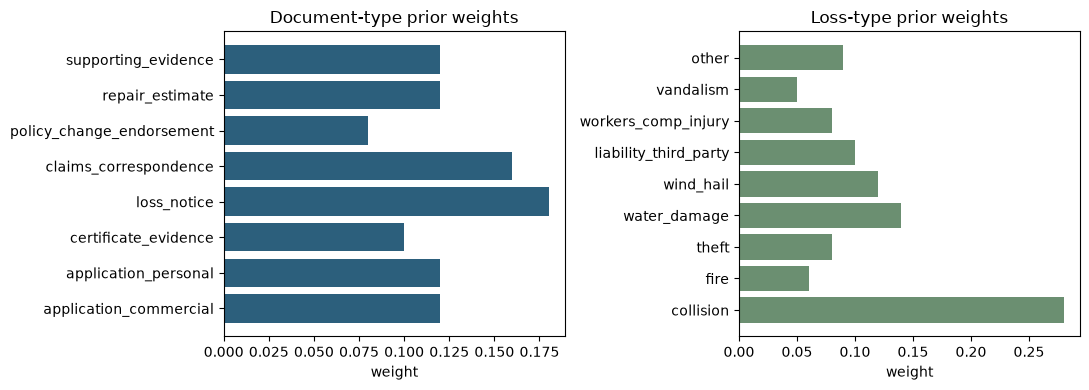

Legal style (vocab only — never used as class labels):
  proximate cause, material fact, coverage determination, reservation of rights, duty to defend, indemnify and hold harmless, preponderance of the evidence, reasonable care …
OCR noise rates: {'char_substitution_rate': 0.025, 'char_deletion_rate': 0.008, 'char_insertion_rate': 0.006}


In [3]:
from src.generation.characteristic_profiler import run_profiler

profile_versions = run_profiler(cfg)
print("Profile versions:")
for name, ver in profile_versions.items():
    print(f"  {name}: {ver}")

dist = read_json(cfg.profiles_dir / "insurance_distributions.json")
legal = read_json(cfg.profiles_dir / "legal_style_profile.json")
ocr = read_json(cfg.profiles_dir / "ocr_noise_profile.json")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
doc_w = dist["document_type_weights"]
axes[0].barh(list(doc_w.keys()), list(doc_w.values()), color="#2c5f7c")
axes[0].set_title("Document-type prior weights")
axes[0].set_xlabel("weight")
loss_w = dist["loss_type_weights"]
axes[1].barh(list(loss_w.keys()), list(loss_w.values()), color="#6b8f71")
axes[1].set_title("Loss-type prior weights")
axes[1].set_xlabel("weight")
plt.tight_layout()
plt.show()

print("Legal style (vocab only — never used as class labels):")
print(" ", ", ".join(legal.get("vocabulary_ngrams", [])[:8]), "…")
print("OCR noise rates:",
      {k: ocr[k] for k in ("char_substitution_rate", "char_deletion_rate", "char_insertion_rate")})


## 3. Skeleton sampling

Each skeleton is a schema-validated claim intermediate (`data/schemas/claim_skeleton.schema.json`) with policy, loss, parties, and financials. Fixed train/val/test splits are written to `data/synthetic/splits.json`.


In [4]:
from src.generation.skeleton_sampler import run_sampler

sk_path = run_sampler(cfg, n=N, seed=SEED, out=DEMO / f"skeletons_n{N}_seed{SEED}.jsonl")
skeletons = load_jsonl(sk_path)
splits = read_json(cfg.splits_path)

print(f"Wrote {len(skeletons)} skeletons → {sk_path}")
print(f"Splits: train={len(splits['train'])}  val={len(splits['val'])}  test={len(splits['test'])}")

type_counts = Counter(s["document_type"] for s in skeletons)
display(pd.DataFrame(type_counts.most_common(), columns=["document_type", "count"]))

sample = skeletons[0]
display(Markdown(f"### Sample skeleton — `{sample['claim_id']}` / `{sample['document_type']}`"))
print(json.dumps(sample, indent=2)[:1800])


Wrote 160 skeletons → /Users/morningstar/Desktop/Cold_Storage/smol-doc-analyzer/data/notebook_demo/skeletons_n160_seed42.jsonl
Splits: train=112  val=24  test=24


,document_type,count
0,supporting_evidence,29
1,claims_correspondence,27
2,loss_notice,26
3,repair_estimate,24
4,application_commercial,15
5,application_personal,14
6,policy_change_endorsement,13
7,certificate_evidence,12


### Sample skeleton — `CLM-2024-117302` / `loss_notice`

{
  "claim_id": "CLM-2024-117302",
  "document_type": "loss_notice",
  "acord_form_number": "2",
  "policy": {
    "policy_number": "TN-480612-Z",
    "policyholder_name": "Rowan Nguyen",
    "state": "TN",
    "coverage_type": "homeowners",
    "effective_date": "2023-06-06"
  },
  "loss_event": {
    "date_of_loss": "2024-07-10",
    "loss_type": "collision",
    "location": "5138 Pine Blvd, TN",
    "description_seed": "rear-end collision at intersection, moderate speed",
    "police_report_filed": true,
    "injuries_reported": false
  },
  "parties": {
    "insured": "Rowan Nguyen",
    "claimant": "Rowan Garcia",
    "adjuster_assigned": "Casey Kim"
  },
  "financials": {
    "estimated_damage": 10672.86,
    "deductible": 1500.0,
    "reserve_set": 9018.76
  },
  "narrative_complexity": "standard",
  "multi_doc_group_id": null,
  "target_outputs": {
    "document_text": null,
    "memo_text": null
  },
  "_record_id": "CLM-2024-117302::loss_notice::0"
}


## 4. Stage A — document generation

Renders insurance document text from each skeleton using layout + surface + legal-style profiles. If `OPENROUTER_API_KEY` is set, an LLM is tried first with template fallback.


In [ ]:
from src.generation.stage_a_document_gen import run_stage_a

doc_path = DEMO / f"documents_n{N}_seed{SEED}.jsonl"
if not doc_path.exists():
    doc_path = run_stage_a(cfg, sk_path, out=doc_path, seed=SEED)
else:
    print(f"reusing existing {doc_path}")
docs = load_jsonl(doc_path)
modes = Counter(d["generation_mode"] for d in docs)
print(f"Documents: {len(docs)}  modes={dict(modes)}")
print(f"→ {doc_path}")

doc = docs[0]
display(Markdown(f"### Sample document — `{doc['document_type']}` (`{doc['generation_mode']}`)"))
print(doc["text"][:2200])


INFO httpx: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 402 Payment Required"
WARNING src.utils.llm_client: OpenRouter paid credits unavailable (APIStatusError); routing to free models
INFO httpx: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO src.utils.llm_client: OpenRouter used free/fallback model openrouter/free
INFO httpx: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO openai._base_client: Retrying request to /chat/completions in 0.408132 seconds
INFO httpx: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 200 OK"
INFO src.utils.llm_client: OpenRouter used free/fallback model openrouter/free
INFO httpx: HTTP Request: POST https://openrouter.ai/api/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
INFO openai._base_client: Retrying request to /chat/completions in 0.459952 seconds
INFO httpx: HTTP Request: POST https://openroute

## 5. Stage B — adjuster memo generation

Produces memo training targets conditioned on the skeleton + Stage A text (issue/rule/application/conclusion style from the legal profile).


In [ ]:
from src.generation.stage_b_memo_gen import run_stage_b

memo_path = DEMO / f"memos_n{N}_seed{SEED}.jsonl"
if not memo_path.exists():
    memo_path = run_stage_b(cfg, doc_path, out=memo_path, seed=SEED)
else:
    print(f"reusing existing {memo_path}")
memos = load_jsonl(memo_path)
print(f"Memos: {len(memos)} → {memo_path}")

memo = memos[0]
display(Markdown(f"### Sample memo — claim `{memo['claim_id']}`"))
print(memo["memo_text"][:2200])


## 6. OCR noise injection

Applies character/word-level OCR artifacts from `ocr_noise_profile.json` and builds a multi-document bundle index for grouped claim files.


In [ ]:
from src.generation.noise_injection import run_noise

noisy_path = DEMO / f"noisy_n{N}_seed{SEED}.jsonl"
if not noisy_path.exists():
    noisy_path = run_noise(cfg, doc_path, out=noisy_path, seed=SEED)
else:
    print(f"reusing existing {noisy_path}")
noisy_docs = load_jsonl(noisy_path)

# Side-by-side clean vs noisy excerpt
clean_excerpt = docs[0]["text"][:500]
noisy_excerpt = noisy_docs[0]["text"][:500]
display(Markdown("### Clean vs OCR-noisy (first ~500 chars)"))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title, text in (
    (axes[0], "Clean", clean_excerpt),
    (axes[1], "Noisy", noisy_excerpt),
):
    ax.axis("off")
    ax.set_title(title)
    ax.text(0.01, 0.99, text, va="top", ha="left", family="monospace", fontsize=8, wrap=True,
            transform=ax.transAxes)
plt.tight_layout()
plt.show()

index_path = cfg.noisy_output_dir / f"multi_doc_index_from_{doc_path.stem}.json"
if index_path.exists():
    index = read_json(index_path)
    print(f"Multi-doc groups: {len(index)}")
    if index:
        gid, members = next(iter(index.items()))
        print(f"  example {gid}: {members}")


## 7. Classification — prepare dataset

Maps Stage A documents → taxonomy labels using the fixed splits. Writes `train/val/test.jsonl` + `label2id.json`.


In [ ]:
from src.classification.prepare_dataset import prepare as prepare_classification

clf_prepared = prepare_classification(doc_path, cfg, out_dir=DEMO / "classification_prepared")
summary = read_json(clf_prepared / "summary.json")
label2id = read_json(clf_prepared / "label2id.json")
print("Prepared:", clf_prepared)
print("Split sizes:", {k: summary[k] for k in ("train", "val", "test")})
print("Labels:", summary["labels"])

train_rows = load_jsonl(clf_prepared / "train.jsonl")
display(pd.Series([r["label"] for r in train_rows]).value_counts().rename("train_count").to_frame())


## 8. Classification — train (smoke)

Smoke mode fine-tunes **DistilBERT** for a few steps on CPU. Full runs use `microsoft/deberta-v3-base` with `SMOKE=False`.


In [ ]:
from src.classification.train_classifier import train as train_classifier

clf_model_dir = train_classifier(
    clf_prepared,
    cfg,
    output_dir=DEMO / "models" / ("classifier_smoke" if SMOKE else "classifier"),
    smoke=SMOKE,
    max_steps=30 if SMOKE else None,
)
meta = read_json(clf_model_dir / "train_meta.json")
print("Saved classifier →", clf_model_dir)
print(json.dumps(meta, indent=2))


## 9. Classification — evaluate

Accuracy, macro-F1, per-class report, and confusion matrix on the held-out test split. Reports also land under `evaluation/reports/`.


In [ ]:
from src.classification.eval import evaluate as eval_classifier
import numpy as np

clf_report = eval_classifier(clf_model_dir, clf_prepared, cfg, split="test")
print(f"accuracy={clf_report['accuracy']:.4f}  macro_f1={clf_report['macro_f1']:.4f}  n={clf_report['n']}")

labels = clf_report["labels"]
cm = np.array(clf_report["confusion_matrix"])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Classifier confusion matrix (test)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j]:
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

if clf_report["top_confusion_pairs"]:
    display(pd.DataFrame(clf_report["top_confusion_pairs"]))
else:
    print("No off-diagonal confusions on this tiny smoke run.")


## 10. Extraction — render forms

Turns document text into page images with word bounding boxes and BIO field labels (claim id, policy number, amounts, dates, …).


In [ ]:
from src.extraction.render_forms import render_documents

rendered_dir = DEMO / "rendered"
rendered_path = render_documents(doc_path, rendered_dir)
rendered = load_jsonl(rendered_path)
print(f"Rendered {len(rendered)} pages → {rendered_path}")

page = rendered[0]
display(Markdown(f"### Rendered page — `{page['document_type']}`"))
display(Image(filename=page["image_path"], width=520))

labeled = [w for w in page["words"] if w.get("label", "O") != "O"]
display(pd.DataFrame(labeled[:20]))
print(f"Non-O tokens on page: {len(labeled)} / {len(page['words'])}")


## 11. Extraction — prepare dataset

Token/bbox/label rows split with the same `splits.json` as classification.


In [ ]:
from src.extraction.prepare_dataset import prepare as prepare_extraction

ext_prepared = prepare_extraction(rendered_path, cfg, out_dir=DEMO / "extraction_prepared")
ext_summary = read_json(ext_prepared / "summary.json")
print("Prepared:", ext_prepared)
print(ext_summary)

# Also prepare noisy renders for stress eval (optional but useful)
noisy_rendered_dir = DEMO / "rendered_noisy"
noisy_rendered_path = render_documents(noisy_path, noisy_rendered_dir)
noisy_ext_prepared = prepare_extraction(
    noisy_rendered_path, cfg, out_dir=DEMO / "extraction_prepared_noisy"
)
print("Noisy prepared:", noisy_ext_prepared)


## 12. Extraction — train (smoke)

Smoke path uses a text-only DistilBERT token classifier (LayoutLMv3 is heavy on CPU). Full runs use `microsoft/layoutlmv3-base` with images + boxes.


In [ ]:
from src.extraction.train_extractor import train as train_extractor

ext_model_dir = train_extractor(
    ext_prepared,
    cfg,
    output_dir=DEMO / "models" / ("extractor_smoke" if SMOKE else "extractor"),
    smoke=SMOKE,
    max_steps=20 if SMOKE else None,
)
ext_meta = read_json(ext_model_dir / "train_meta.json")
print("Saved extractor →", ext_model_dir)
print(json.dumps(ext_meta, indent=2))


## 13. Extraction — evaluate (+ noisy stress)

Token macro-F1, field exact/partial match, hard-field breakdown, and optional noisy-split stress metrics. Writes `evaluation/reports/extraction_report.json` and `failure_modes.md`.


In [ ]:
from src.extraction.eval import evaluate as eval_extractor

ext_report = eval_extractor(
    ext_model_dir,
    ext_prepared,
    cfg,
    split="test",
    noisy_prepared=noisy_ext_prepared,
)
print(
    f"token_macro_f1={ext_report['token_macro_f1']:.4f}  "
    f"field_exact={ext_report['field_exact_mean']:.4f}  "
    f"field_partial={ext_report['field_partial_mean']:.4f}"
)
if ext_report.get("noisy_stress"):
    print("noisy stress:", ext_report["noisy_stress"])

hard = pd.Series(ext_report["hard_fields"]).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
hard.plot(kind="barh", ax=ax, color="#8b5e3c")
ax.set_xlim(0, 1)
ax.set_xlabel("partial-match rate")
ax.set_title("Hard-field partial match (test)")
plt.tight_layout()
plt.show()

display(Markdown("### Failure-mode notes"))
print((cfg.evaluation_reports_dir / "failure_modes.md").read_text(encoding="utf-8"))


## 14. End-to-end inference on one document

Classify a held-out document, run token-level field extraction, and show the paired Stage B memo (the Phase 4 summarization target — not yet a trained local generator).


In [ ]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    AutoTokenizer,
)

test_rows = load_jsonl(clf_prepared / "test.jsonl")
assert test_rows, "Need at least one test row — raise N if empty"
row = test_rows[0]
record_id = row["record_id"]

# --- Classify ---
clf_tok = AutoTokenizer.from_pretrained(str(clf_model_dir))
clf_model = AutoModelForSequenceClassification.from_pretrained(str(clf_model_dir))
clf_model.eval()
with torch.no_grad():
    inputs = clf_tok(row["text"], return_tensors="pt", truncation=True, max_length=512)
    pred_id = int(torch.argmax(clf_model(**inputs).logits, dim=-1).item())
pred_label = clf_model.config.id2label[pred_id]

# --- Extract fields from matching rendered page ---
ext_test = {r["record_id"]: r for r in load_jsonl(ext_prepared / "test.jsonl")}
ext_row = ext_test.get(record_id) or load_jsonl(ext_prepared / "train.jsonl")[0]
ext_tok = AutoTokenizer.from_pretrained(str(ext_model_dir))
ext_model = AutoModelForTokenClassification.from_pretrained(str(ext_model_dir))
ext_model.eval()
id2label = {int(v): k for k, v in read_json(ext_model_dir / "label2id.json").items()}

enc = ext_tok(
    ext_row["tokens"],
    is_split_into_words=True,
    return_tensors="pt",
    truncation=True,
    max_length=256,
)
with torch.no_grad():
    pred_ids = torch.argmax(ext_model(**enc).logits, dim=-1)[0].tolist()
word_ids = enc.word_ids(batch_index=0)
aligned = ["O"] * len(ext_row["tokens"])
seen = set()
for idx, wid in enumerate(word_ids):
    if wid is None or wid in seen:
        continue
    seen.add(wid)
    aligned[wid] = id2label.get(int(pred_ids[idx]), "O")

# Decode BIO spans
from src.extraction.eval import _decode_entities

pred_ents = _decode_entities(ext_row["tokens"], aligned)
gold_ents = _decode_entities(
    ext_row["tokens"], [id2label.get(int(i), "O") for i in ext_row["labels"]]
)

# --- Paired memo ---
memo_by_id = {m["record_id"]: m for m in memos}
paired_memo = memo_by_id.get(record_id)

display(Markdown(f"### Record `{record_id}`"))
print(f"Gold label:      {row['label']}")
print(f"Predicted label: {pred_label}")
print()
print("Extracted fields (pred vs gold):")
fields = sorted(set(pred_ents) | set(gold_ents))
for f in fields:
    pvals = pred_ents.get(f) or []
    gvals = gold_ents.get(f) or []
    pred_s = (pvals[0][:60] if pvals else "—")
    gold_s = (gvals[0][:60] if gvals else "—")
    print(f"  {f:22s}  pred={pred_s}")
    print(f"  {'':22s}  gold={gold_s}")

if paired_memo:
    display(Markdown("### Paired Stage B memo (summarization training target)"))
    print(paired_memo["memo_text"][:1800])


## 15. Provenance audit log

Every generation and training stage appends a record to `data/provenance_log.jsonl`.


In [ ]:
prov_path = cfg.provenance_log_path
if prov_path.exists():
    prov = load_jsonl(prov_path)
    # Show the most recent entries from this notebook run
    recent = prov[-12:]
    display(pd.DataFrame(
        [
            {
                "stage": r.get("stage"),
                "source": str(r.get("source", ""))[:50],
                "model": r.get("model"),
                "prompt_version": r.get("prompt_version"),
            }
            for r in recent
        ]
    ))
    print(f"Total provenance records: {len(prov)}  → {prov_path}")
else:
    print("No provenance log yet.")


## 16. Pipeline map & next steps

```
Public priors / optional Hub ingest
        ↓
Characteristic profiles
        ↓
Claim skeletons ──► Stage A documents ──► Stage B memos (Phase 4 targets)
        │                    │
        │                    ├── OCR-noisy variants
        │                    ↓
        │              Classification (DeBERTa / DistilBERT smoke)
        │                    ↓
        │              Form render + Extraction (LayoutLMv3 / DistilBERT smoke)
        ↓
Fixed splits.json reused across train/eval
```

| Phase | Status in this notebook |
|-------|-------------------------|
| 0 Taxonomy / schema / config | ✅ inspected |
| 1 Synthetic generation + noise | ✅ ran |
| 2 Classification train/eval | ✅ smoke |
| 3 Extraction train/eval | ✅ smoke |
| 4 Summarization LoRA | ❌ not implemented — template memo + optional local generative hook |
| 5 Orchestrated intake pipeline | ✅ implemented (`src/pipeline/`) |

**Scale up:** set `N=240` (or 5000), `SMOKE=False`, and optionally export `OPENROUTER_API_KEY` for LLM Stage A/B. CLI equivalents are in the README quickstart.


In [ ]:
print("Demo artifact summary")
print("=" * 60)
for label, path in [
    ("skeletons", sk_path),
    ("documents", doc_path),
    ("memos", memo_path),
    ("noisy", noisy_path),
    ("clf prepared", clf_prepared),
    ("clf model", clf_model_dir),
    ("rendered", rendered_path),
    ("ext prepared", ext_prepared),
    ("ext model", ext_model_dir),
    ("clf report", cfg.evaluation_reports_dir / "classification_report.json"),
    ("ext report", cfg.evaluation_reports_dir / "extraction_report.json"),
]:
    print(f"{label:14s} {path}")
